In [2]:
import matplotlib.pyplot as plt
from os import walk
import json
import numpy as np 

In [6]:
log_origin  = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/results-origin/output-resnet50-O01/output-resnet50-N1.out'
log_new     = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-M01/output-resnet50-M1.out'
log_new_all = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-M01-1500/output-resnet50-1500-M1.out'

In [7]:
f_origin  = open(log_origin, "r")
f_new     = open(log_new, "r")
f_new_all = open(log_new_all, "r")

result_origin_dic = {}
result_new_dic = {}
result_new_all_dic = {}
for line in f_new:
    if("task tune" in line):
        result = line.split("task tune:  ")[1].replace("\n", "")
        last = result.split(" ")
        last = last[len(last)-1]
        key = result.replace(" "+last, "")
        result_new_dic[key] = float(last)
for line in f_origin:
    if("task tune" in line):
        result = line.split("task tune:  ")[1].replace("\n", "")
        last = result.split(" ")
        last = last[len(last)-1]
        key = result.replace(" "+last, "")
        result_origin_dic[key] = float(last)
for line in f_new_all:
    if("task tune" in line):
        result = line.split("task tune:  ")[1].replace("\n", "")
        last = result.split(" ")
        last = last[len(last)-1]
        key = result.replace(" "+last, "")
        result_new_all_dic[key] = float(last)

In [9]:
speedup = []
speedup_all = []
for key in result_new_dic:
    speedup.append(result_origin_dic[key]/result_new_dic[key])
    speedup_all.append(result_origin_dic[key]/result_new_all_dic[key])

<BarContainer object of 25 artists>

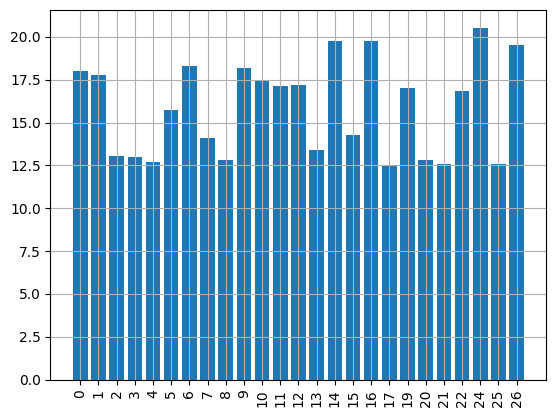

In [10]:
x = []
y = []
idx = 0
for v in np.arange(len(speedup)):
    if(v != 18 and v != 23):
        x.append(str(v))
        y.append(speedup[idx])
    idx += 1
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, y)


<BarContainer object of 25 artists>

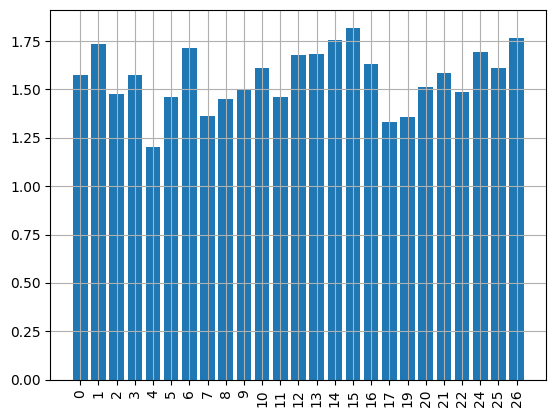

In [11]:
x = []
y = []
idx = 0
for v in np.arange(len(speedup_all)):
    if(v != 18 and v != 23):
        x.append(str(v))
        y.append(speedup_all[idx])
    idx += 1
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, y)

In [39]:
mypath_new     = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-M01/'
mypath_origin  = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/results-origin/output-resnet50-O01/'
mypath_new_all = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-M01-1500/'
mypath_new_all = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-M02-1500/'

filenames_origin  = next(walk(mypath_origin), (None, None, []))[2]  # [] if no file
filenames_new     = next(walk(mypath_new), (None, None, []))[2]  # [] if no file
filenames_new_all = next(walk(mypath_new_all), (None, None, []))[2]  # [] if no file

values_origin = {}
for name in filenames_origin:
    if(".json" in name):
        f = open(mypath_origin + name, "r")
        best = 100000
        for line in f:
            result = json.loads(line)
            task = result['i'][0][0]
            r = sum(result['r'][0])/len(result['r'][0])
            if(task not in values_origin):
                values_origin[task] = []
            if(r < best):
                best = r
            if(r < 1000):
                values_origin[task].append(r)

values_new = {}
for name in filenames_new:
    if(".json" in name):
        f = open(mypath_new + name, "r")
        best = 100000
        for line in f:
            result = json.loads(line)
            task = result['i'][0][0]
            r = sum(result['r'][0])/len(result['r'][0])
            if(task not in values_new):
                values_new[task] = []
            if(r < best):
                best = r
            if(r < 1000):
                values_new[task].append(r)

values_new_all = {}
for name in filenames_new_all:
    if(".json" in name):
        f = open(mypath_new_all + name, "r")
        best = 100000
        for line in f:
            result = json.loads(line)
            task = result['i'][0][0]
            r = sum(result['r'][0])/len(result['r'][0])
            if(task not in values_new_all):
                values_new_all[task] = []
            if(r < best):
                best = r
            if(r < 1000):
                values_new_all[task].append(r)

In [40]:
speedup = []
speedup_all = []
speedup_sum = []
speedup_real = []
speedup_sum_real = []
for idx, key in enumerate(values_new):
    if(len(values_new[key])):
        speedup.append(min(values_origin[key])/min(values_new[key]))
        speedup_real.append(min(values_origin[key][0:128])/min(values_new[key]))
        speedup_all.append(min(values_origin[key])/min(values_new_all[key]))
        #speedup_sum.append(sum(values_origin[key])/sum(values_new_all[key]))
        #speedup_sum_real.append(sum(values_origin[key][0:64])/sum(values_new[key][0:64]))

<BarContainer object of 26 artists>

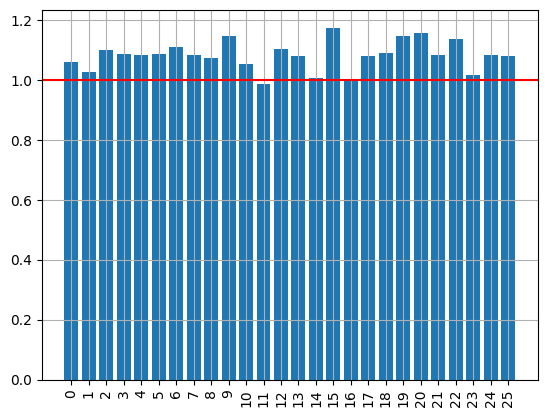

In [41]:
x = []
for v in np.arange(len(speedup_all)):
    x.append(str(v))
plt.axhline(y=1, color='r', linestyle='-')
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, speedup_all)

<BarContainer object of 26 artists>

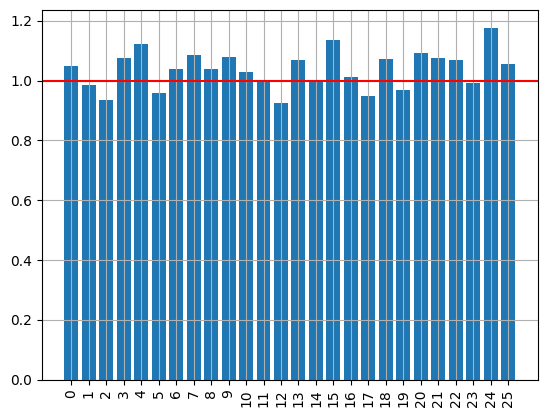

In [42]:
x = []
for v in np.arange(len(speedup)):
    x.append(str(v))
plt.axhline(y=1, color='r', linestyle='-')
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, speedup)

<BarContainer object of 26 artists>

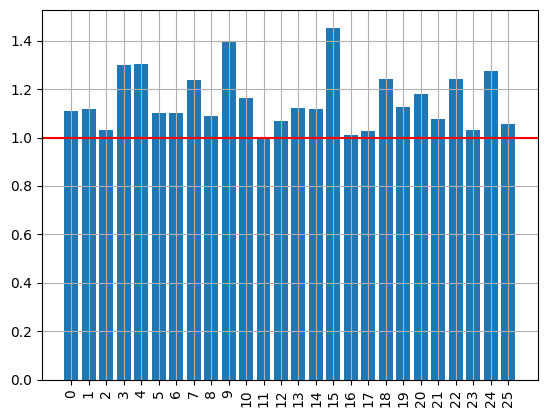

In [43]:
x = []
for v in np.arange(len(speedup_real)):
    x.append(str(v))
plt.axhline(y=1, color='r', linestyle='-')
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, speedup_real)

<BarContainer object of 26 artists>

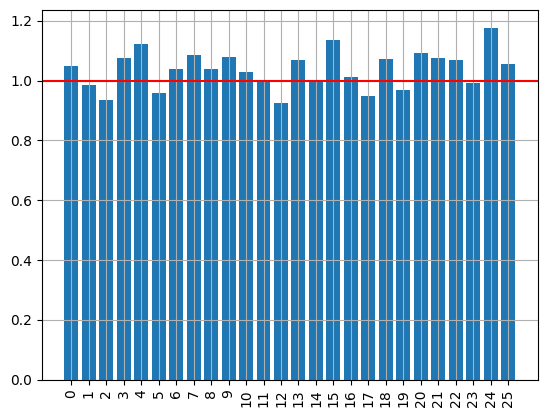

In [44]:
x = []
for v in np.arange(len(speedup)):
    x.append(str(v))
plt.axhline(y=1, color='r', linestyle='-')
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, speedup)

["cb5e1bf27549411a1320749a1d8e07ca", [1, 56, 56, 256], [1, 1, 256, 512], [1, 1, 1, 512], [1, 28, 28, 512]]


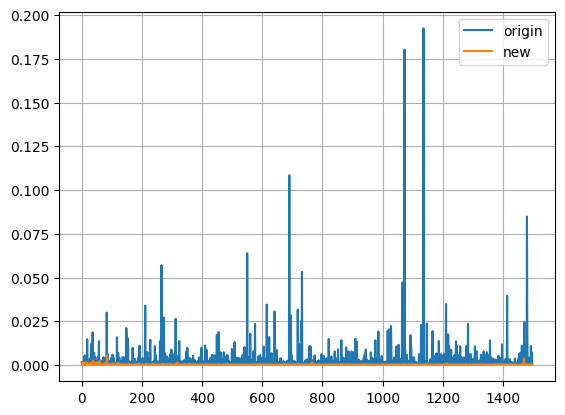

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 1024], [1, 1, 1024, 512], [1, 1, 1, 512], [1, 14, 14, 512]]


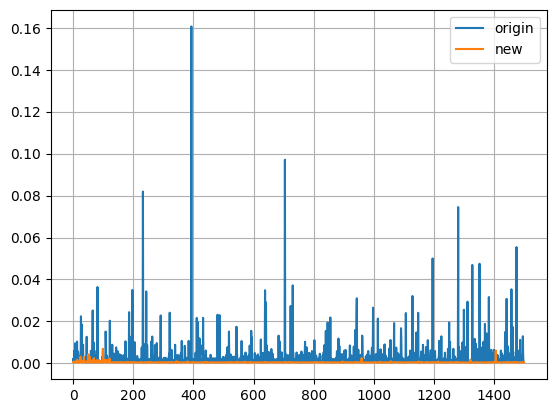

["09e1468652ad0039f0b726123db6e54d", [1, 7, 7, 512], [1, 1, 512, 2048], [1, 1, 1, 2048], [1, 7, 7, 2048], [1, 7, 7, 2048]]


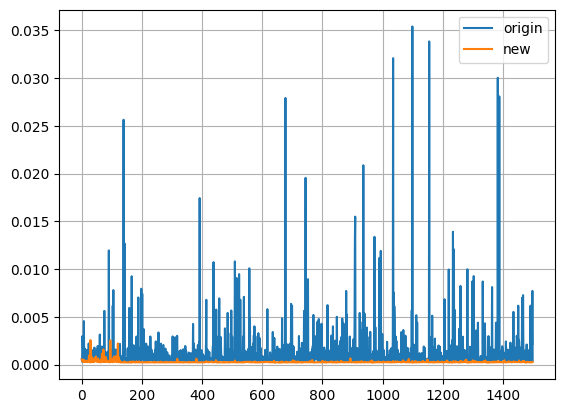

["6d628209072e3e3dd8f49359935acea6", [1, 56, 56, 256], [1, 1, 256, 128], [1, 1, 1, 128], [1, 56, 56, 128]]


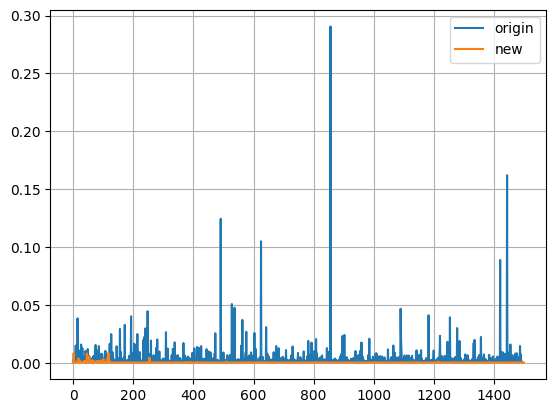

["07f9fcad27bdd3233f86fe35a5185d33", [1, 14, 14, 512], [3, 3, 512, 512], [1, 1, 1, 512], [1, 7, 7, 512]]


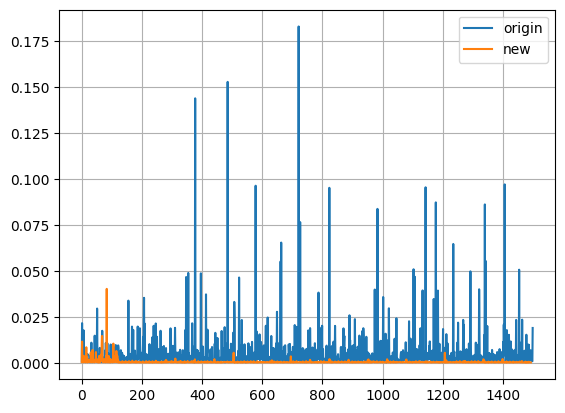

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 2048], [1, 1, 2048, 512], [1, 1, 1, 512], [1, 7, 7, 512]]


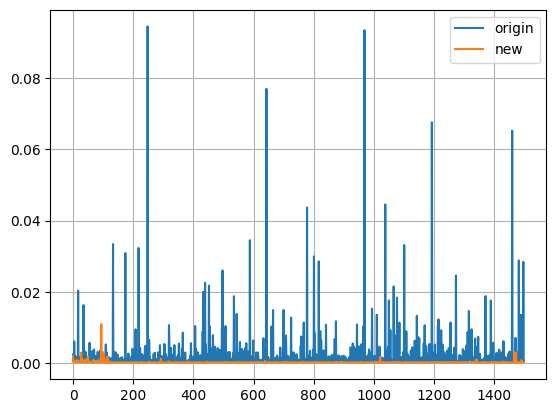

["d37380659057397544e056461ea3bad3", [1, 56, 56, 64], [3, 3, 64, 64], [1, 1, 1, 64], [1, 56, 56, 64]]


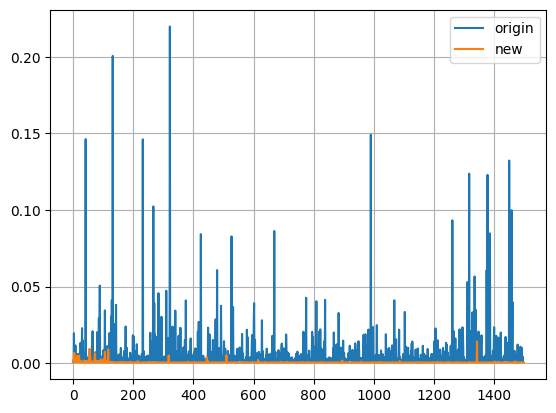

["cb7a0e9e733d26ffc00e7f6c9cc0f879", [1, 56, 56, 64], [1, 1, 64, 256], [1, 1, 1, 256], [1, 56, 56, 256]]


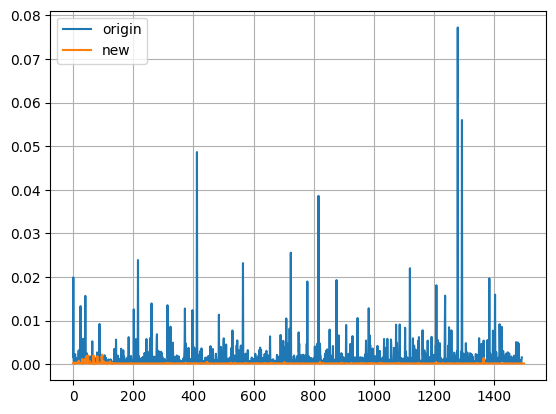

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 1024], [1, 1, 1024, 256], [1, 1, 1, 256], [1, 14, 14, 256]]


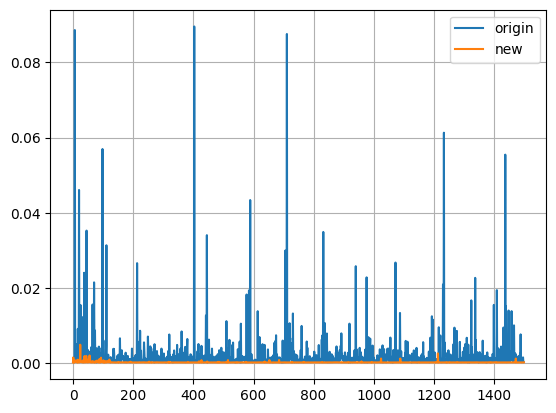

["d37380659057397544e056461ea3bad3", [1, 7, 7, 512], [3, 3, 512, 512], [1, 1, 1, 512], [1, 7, 7, 512]]


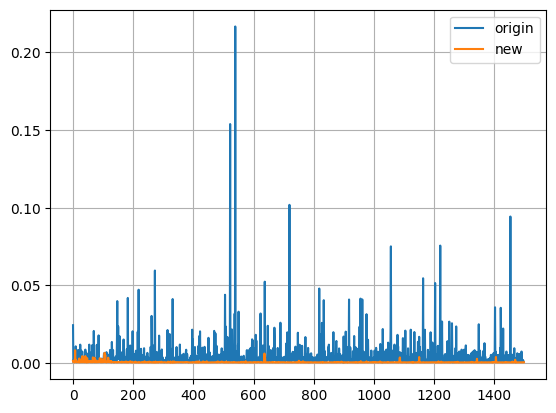

["cb5e1bf27549411a1320749a1d8e07ca", [1, 14, 14, 1024], [1, 1, 1024, 2048], [1, 1, 1, 2048], [1, 7, 7, 2048]]


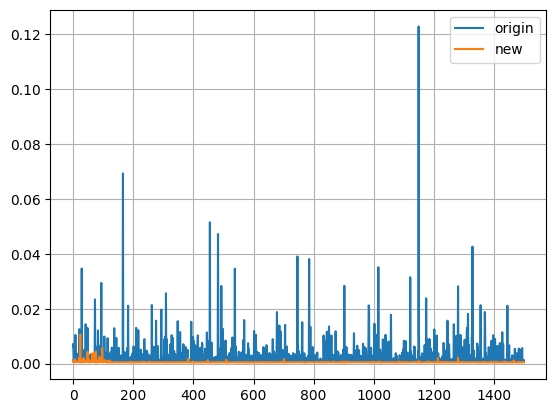

["8c53ca2904398da2889aa7508082d7bb", [1, 7, 7, 2048], [1, 1, 1, 2048]]


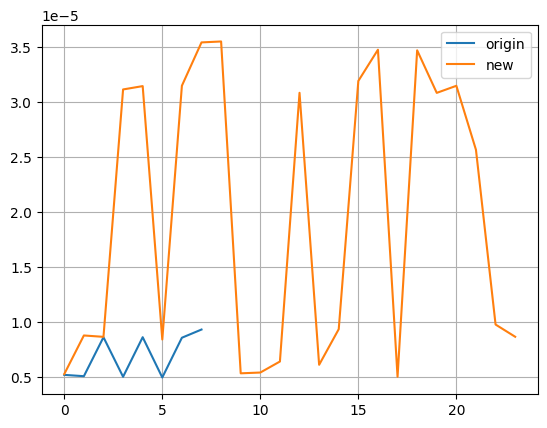

["09e1468652ad0039f0b726123db6e54d", [1, 28, 28, 128], [1, 1, 128, 512], [1, 1, 1, 512], [1, 28, 28, 512], [1, 28, 28, 512]]


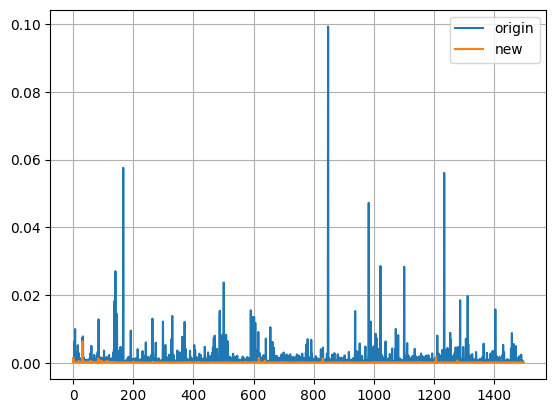

["6d628209072e3e3dd8f49359935acea6", [1, 56, 56, 64], [1, 1, 64, 64], [1, 1, 1, 64], [1, 56, 56, 64]]


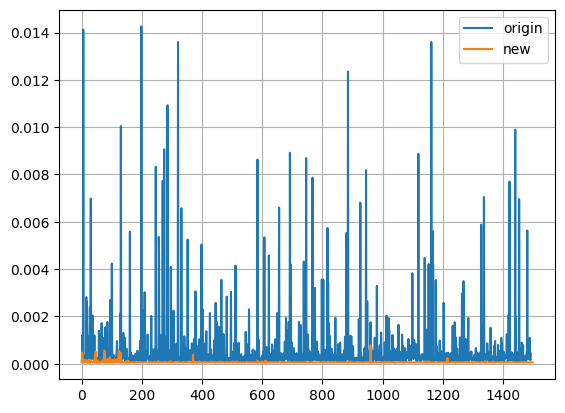

["6d628209072e3e3dd8f49359935acea6", [1, 28, 28, 512], [1, 1, 512, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


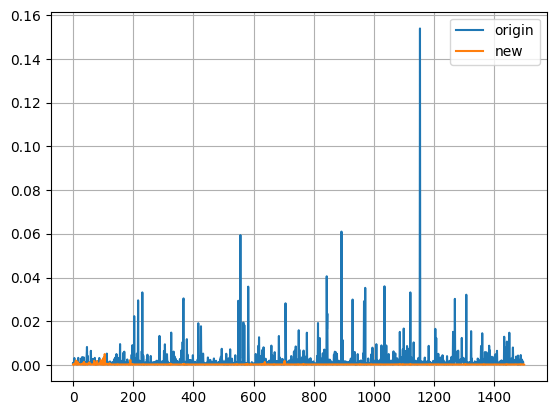

["38552500208b25b4035682b0e93cbce3", [1, 14, 14, 256], [6, 6, 256, 256], [1, 1, 1, 256], [1, 14, 14, 256]]


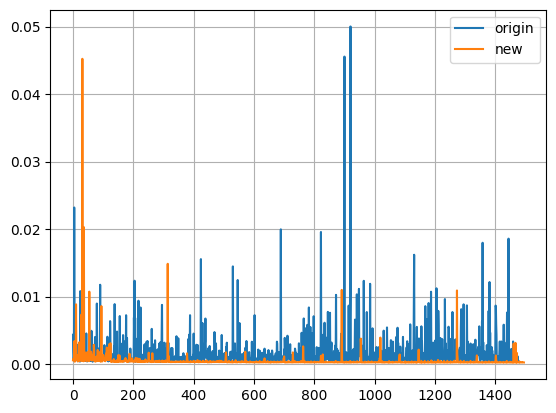

["c219de5fa5fe694343f2826ebe8e47ce", [1, 112, 112, 64], [1, 56, 56, 64]]


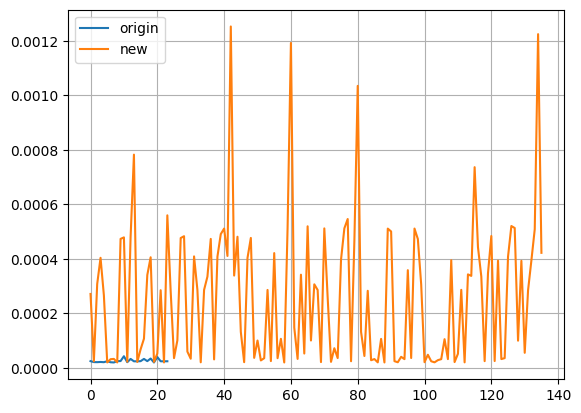

["09e1468652ad0039f0b726123db6e54d", [1, 14, 14, 256], [1, 1, 256, 1024], [1, 1, 1, 1024], [1, 14, 14, 1024], [1, 14, 14, 1024]]


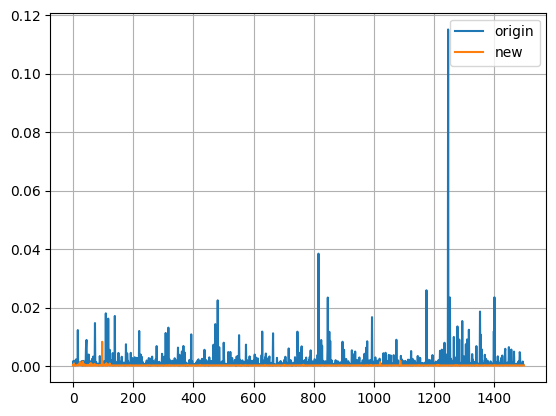

["6d628209072e3e3dd8f49359935acea6", [1, 28, 28, 512], [1, 1, 512, 256], [1, 1, 1, 256], [1, 28, 28, 256]]


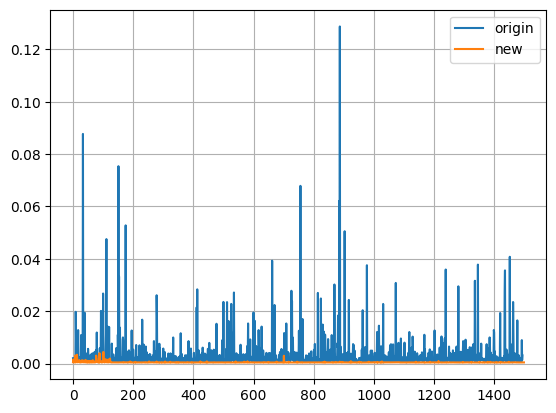

["09e1468652ad0039f0b726123db6e54d", [1, 56, 56, 64], [1, 1, 64, 256], [1, 1, 1, 256], [1, 56, 56, 256], [1, 56, 56, 256]]


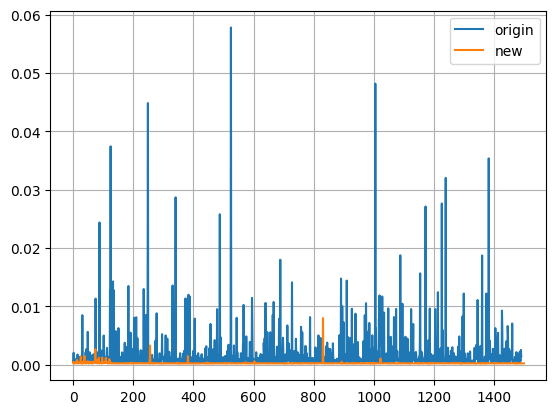

["07f9fcad27bdd3233f86fe35a5185d33", [1, 56, 56, 128], [3, 3, 128, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


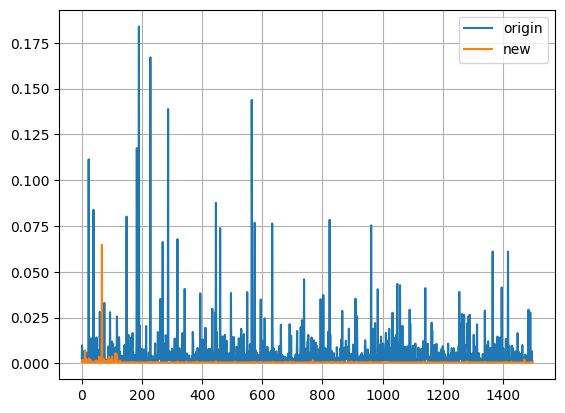

["6d628209072e3e3dd8f49359935acea6", [1, 56, 56, 256], [1, 1, 256, 64], [1, 1, 1, 64], [1, 56, 56, 64]]


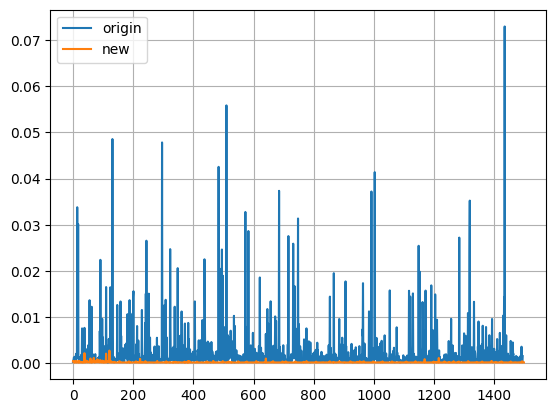

["07f9fcad27bdd3233f86fe35a5185d33", [1, 28, 28, 256], [3, 3, 256, 256], [1, 1, 1, 256], [1, 14, 14, 256]]


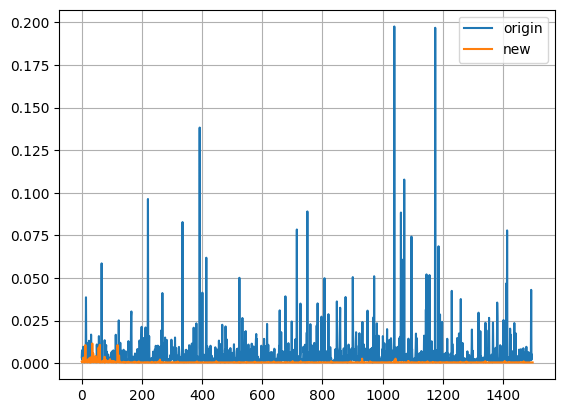

["cb5e1bf27549411a1320749a1d8e07ca", [1, 28, 28, 512], [1, 1, 512, 1024], [1, 1, 1, 1024], [1, 14, 14, 1024]]


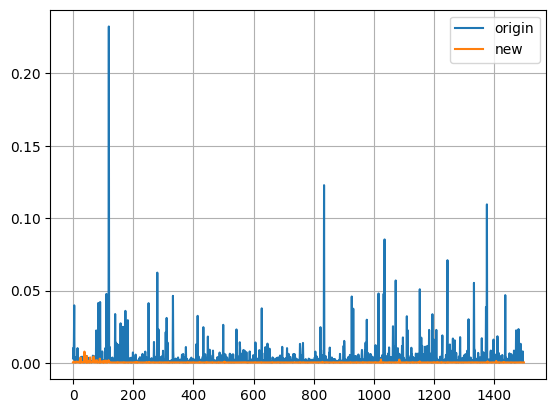

["cfd09cf1ca9e943f0ee12a18813a5c75", [1, 28, 28, 128], [6, 6, 128, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


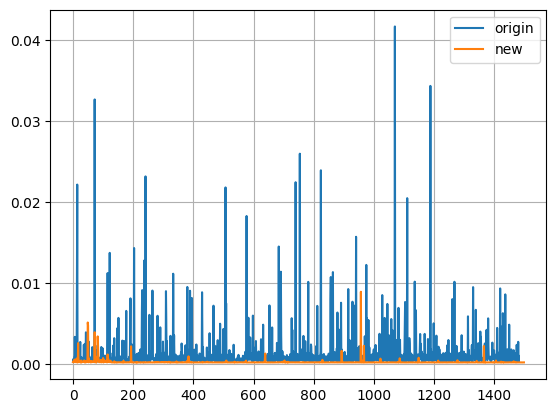

["07f9fcad27bdd3233f86fe35a5185d33", [1, 224, 224, 3], [7, 7, 3, 64], [1, 1, 1, 64], [1, 112, 112, 64]]


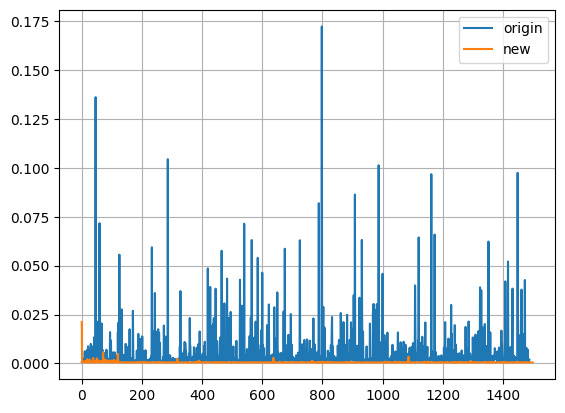

In [45]:
for idx, task in enumerate(values_new):
    if(len(values_origin[task])):
        print(task)
        #plt.figure(figsize=(25, 7))
        #plt.plot(values_origin[task][0:800])
        #plt.plot(values_new_all[task][0:800])
        plt.plot(values_origin[task], label="origin")
        plt.plot(values_new_all[task], label="new")
        #plt.plot(values_new[task], label="new", color='black')
        plt.legend()
        plt.grid()
        plt.show()